In [1]:
import pandas as pd
import numpy as np
import random



In [2]:
np.random.seed(42)



In [3]:
RECORDS = 20000

vehicle_data = {
    "Toyota": ["Corolla", "Axio", "Prado", "Harrier"],
    "Nissan": ["Note", "Xtrail", "Navara"],
    "Mazda": ["Demio", "CX5"],
    "Subaru": ["Forester", "Impreza"],
    "Honda": ["Fit", "CRV"],
    "Isuzu": ["Dmax"],
    "Mitsubishi": ["Outlander", "Pajero"]
}

counties = [
    "Nairobi","Kiambu","Mombasa","Nakuru","Machakos",
    "Kisumu","Uasin Gishu","Meru","Nyeri","Kajiado",
    "Kakamega","Bungoma","Kericho","Embu","Kilifi"
]

vehicle_types = [
    "Sedan",
    "SUV",
    "Hatchback",
    "Pickup"
]

policy_types = [
    "Comprehensive",
    "Third Party"
]

data = []

for i in range(RECORDS):

    driver_age = np.random.randint(18, 75)

    gender = random.choice(["Male", "Female"])

    driving_experience = max(
        0,
        driver_age - np.random.randint(18, 30)
    )

    make = random.choice(list(vehicle_data.keys()))

    model = random.choice(vehicle_data[make])

    vehicle_type = random.choice(vehicle_types)

    vehicle_age = np.random.randint(0, 20)

    engine_capacity = np.random.choice(
        [1000,1200,1300,1500,1800,2000,2500,3000]
    )

    vehicle_value = np.random.randint(
        300000,
        10000000
    )

    county = random.choice(counties)

    annual_mileage = np.random.randint(
        5000,
        60000
    )

    previous_claims = np.random.poisson(1.2)

    claim_amount_history = (
        previous_claims *
        np.random.randint(10000,250000)
    )

    no_claim_bonus = random.choice([0,1])

    policy_type = random.choice(policy_types)

    accident_risk_index = round(
        np.random.uniform(0.2,1.0),
        2
    )

    theft_risk_index = round(
        np.random.uniform(0.2,1.0),
        2
    )

    driver_risk_score = round(
        (
            previous_claims * 15 +
            accident_risk_index * 30 +
            theft_risk_index * 20 +
            (75-driver_age)*0.5
        ),
        2
    )

    base_premium = 10000

    premium = (
        base_premium
        + vehicle_value * 0.015
        + previous_claims * 6000
        + accident_risk_index * 15000
        + theft_risk_index * 10000
        + (3000 if engine_capacity >= 2000 else 0)
        - driving_experience * 100
        - no_claim_bonus * 5000
    )

    premium = max(
        premium,
        5000
    )

    data.append([
        i+1,
        driver_age,
        gender,
        driving_experience,
        make,
        model,
        vehicle_type,
        vehicle_age,
        engine_capacity,
        vehicle_value,
        county,
        annual_mileage,
        previous_claims,
        claim_amount_history,
        no_claim_bonus,
        policy_type,
        accident_risk_index,
        theft_risk_index,
        driver_risk_score,
        round(premium,2)
    ])

columns = [
    "policy_id",
    "driver_age",
    "gender",
    "driving_experience",
    "vehicle_make",
    "vehicle_model",
    "vehicle_type",
    "vehicle_age",
    "engine_capacity",
    "vehicle_value",
    "county",
    "annual_mileage",
    "previous_claims",
    "claim_amount_history",
    "no_claim_bonus",
    "policy_type",
    "accident_risk_index",
    "theft_risk_index",
    "driver_risk_score",
    "premium_amount"
]

df = pd.DataFrame(
    data,
    columns=columns
)

df.to_csv(
    "kenya_motor_insurance_dataset.csv",
    index=False
)

print(df.head())
print()
print("Dataset Generated Successfully")
print("Rows:", len(df))

   policy_id  driver_age  gender  driving_experience vehicle_make  \
0          1          56    Male                  35        Isuzu   
1          2          70    Male                  49       Toyota   
2          3          39  Female                  10       Subaru   
3          4          68    Male                  39        Mazda   
4          5          67  Female                  40   Mitsubishi   

  vehicle_model vehicle_type  vehicle_age  engine_capacity  vehicle_value  \
0          Dmax          SUV           14             1300        4604572   
1          Axio    Hatchback            7             3000        4823669   
2       Impreza        Sedan           16             1300        6413790   
3         Demio          SUV           19             3000        8542680   
4     Outlander          SUV            8             1200         368148   

        county  annual_mileage  previous_claims  claim_amount_history  \
0  Uasin Gishu           16284                0  

In [4]:
import pandas as pd

df = pd.read_csv("kenya_motor_insurance_dataset.csv")

print(df.shape)
print(df.head())

(20000, 20)
   policy_id  driver_age  gender  driving_experience vehicle_make  \
0          1          56    Male                  35        Isuzu   
1          2          70    Male                  49       Toyota   
2          3          39  Female                  10       Subaru   
3          4          68    Male                  39        Mazda   
4          5          67  Female                  40   Mitsubishi   

  vehicle_model vehicle_type  vehicle_age  engine_capacity  vehicle_value  \
0          Dmax          SUV           14             1300        4604572   
1          Axio    Hatchback            7             3000        4823669   
2       Impreza        Sedan           16             1300        6413790   
3         Demio          SUV           19             3000        8542680   
4     Outlander          SUV            8             1200         368148   

        county  annual_mileage  previous_claims  claim_amount_history  \
0  Uasin Gishu           16284       

In [5]:
print(df.info())

print(df.isnull().sum())

print(df["premium_amount"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   policy_id             20000 non-null  int64  
 1   driver_age            20000 non-null  int64  
 2   gender                20000 non-null  object 
 3   driving_experience    20000 non-null  int64  
 4   vehicle_make          20000 non-null  object 
 5   vehicle_model         20000 non-null  object 
 6   vehicle_type          20000 non-null  object 
 7   vehicle_age           20000 non-null  int64  
 8   engine_capacity       20000 non-null  int64  
 9   vehicle_value         20000 non-null  int64  
 10  county                20000 non-null  object 
 11  annual_mileage        20000 non-null  int64  
 12  previous_claims       20000 non-null  int64  
 13  claim_amount_history  20000 non-null  int64  
 14  no_claim_bonus        20000 non-null  int64  
 15  policy_type        

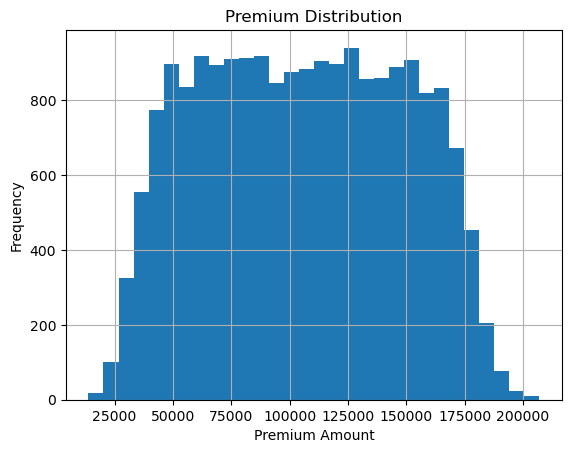

In [6]:
import matplotlib.pyplot as plt

df["premium_amount"].hist(bins=30)

plt.title("Premium Distribution")
plt.xlabel("Premium Amount")
plt.ylabel("Frequency")

plt.show()

In [7]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

print(corr["premium_amount"].sort_values(ascending=False))

premium_amount          1.000000
vehicle_value           0.980333
driver_risk_score       0.180645
previous_claims         0.154415
claim_amount_history    0.132812
accident_risk_index     0.076119
theft_risk_index        0.057714
engine_capacity         0.019734
annual_mileage          0.004458
vehicle_age            -0.005224
policy_id              -0.007118
driving_experience     -0.036604
driver_age             -0.036660
no_claim_bonus         -0.057471
Name: premium_amount, dtype: float64
